In [1]:
import pandas as pd

df = pd.read_csv("/Users/rafaeltanizawa/Downloads/decision_tree/ign_games.csv")
df = df.drop("sample", axis = 1)
df = df.drop("jogo", axis = 1)
df = df.drop("distribuidor", axis = 1)
df = df.drop("desenvolvedor", axis = 1)
df = df.drop("quantos_desejam", axis = 1)

df["plataforma"] = df.plataforma.astype("category").cat.codes
df["genero"] = df.genero.astype("category").cat.codes

df.head()

,plataforma,genero,nota_do_usuarios,nota_do_site,quantos_possuem,numero_de_jogadores,ano_de_lancamento
0,1,2,8.4,10.0,2380,2,2001
1,1,0,9.2,9.2,56420,2,2004
2,1,0,9.2,9.6,12481,1,2002
3,1,2,8.2,9.6,398,2,2002
4,1,0,9.3,9.6,8882,1,2001


In [2]:
target_name = "plataforma"
target = df[target_name]
target.value_counts(normalize=True)

plataforma
1    0.2
2    0.2
0    0.2
4    0.2
3    0.2
Name: proportion, dtype: float64

In [3]:
df = df.drop(target_name, axis = 1)

In [4]:
from sklearn.compose import make_column_selector as selector
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

#categorical_column_selector = selector(dtype_include=object)
#categorical_columns = categorical_column_selector(df)
#data_categorical = df[categorical_columns]
#data_categorical = pd.get_dummies(data_categorical, drop_first=True)

#numerical_columns_selector = selector(dtype_exclude=object)
#numerical_columns = numerical_columns_selector(df)
#data_numeric = df[numerical_columns]

#frames = [data_categorical, data_numeric]
#data = pd.concat(frames, axis=1, join="inner")
data = df
data

,genero,nota_do_usuarios,nota_do_site,quantos_possuem,numero_de_jogadores,ano_de_lancamento
0,2,8.4,10.0,2380,2,2001
1,0,9.2,9.2,56420,2,2004
2,0,9.2,9.6,12481,1,2002
3,2,8.2,9.6,398,2,2002
4,0,9.3,9.6,8882,1,2001
...,...,...,...,...,...,...
145,2,7.5,8.0,160,4,2007
146,2,8.2,8.0,16,2,2007
147,0,7.7,8.0,43,1,2007
148,0,8.3,8.0,27,1,2007


Training data has: 112 records
Training data has: 38 records
Training: 75%, Test: 25%


[Text(0.4868421052631579, 0.9, 'genero_estrategia <= 9.05\nentropy = 2.31\nsamples = 112\nvalue = [26, 22, 23, 22, 19]\nclass = ps2'),
 Text(0.23684210526315788, 0.7, 'genero_luta <= 322.5\nentropy = 1.94\nsamples = 79\nvalue = [25, 0, 23, 20, 11]\nclass = ps2'),
 Text(0.10526315789473684, 0.5, 'genero_party_game <= 2006.5\nentropy = 0.32\nsamples = 17\nvalue = [0, 0, 1, 16, 0]\nclass = xbox360'),
 Text(0.05263157894736842, 0.3, 'entropy = 0.0\nsamples = 1\nvalue = [0, 0, 1, 0, 0]\nclass = ds'),
 Text(0.15789473684210525, 0.3, 'entropy = 0.0\nsamples = 16\nvalue = [0, 0, 0, 16, 0]\nclass = xbox360'),
 Text(0.3684210526315789, 0.5, 'genero_party_game <= 2006.5\nentropy = 1.76\nsamples = 62\nvalue = [25, 0, 22, 4, 11]\nclass = ps2'),
 Text(0.2631578947368421, 0.3, 'genero_corrida <= 8.5\nentropy = 1.3\nsamples = 41\nvalue = [20, 0, 18, 0, 3]\nclass = ps2'),
 Text(0.21052631578947367, 0.1, 'entropy = 1.14\nsamples = 35\nvalue = [20, 0, 14, 0, 1]\nclass = ps2'),
 Text(0.3157894736842105, 0

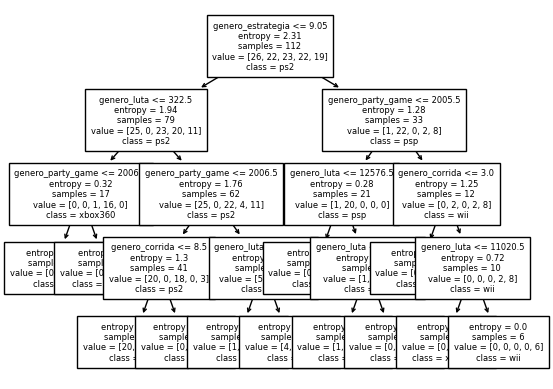

In [9]:
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

data_train, data_test, target_train, target_test = train_test_split(
    data, target, random_state=24
)

print(f"Training data has: {data_train.shape[0]} records")
print(f"Training data has: {data_test.shape[0]} records")

training_pct = data_train.shape[0] / data.shape[0]
print(f"Training: {training_pct:.0%}, Test: {(1-training_pct):.0%}")

clf = DecisionTreeClassifier(
    criterion="entropy", 
    max_depth=4,
    splitter='best'
)
clf = clf.fit(data_train, target_train)

tree.plot_tree(
    clf,
    max_depth=None, 
    feature_names=['genero_corrida','genero_esporte','genero_estrategia','genero_luta','genero_musica','genero_party_game','genero_puzzle','genero_rpg','genero_tiro','nota_do_usuarios','nota_do_site','quantos_possuem','numero_de_jogadores','ano_de_lancamento'],
    class_names=['ps2','psp','ds','xbox360','wii'], 
    label='all',
    filled=False, 
    impurity=True, 
    node_ids=False, 
    proportion=False,
    rounded=False, 
    precision=2,
    ax=None, 
    fontsize=6
)

In [10]:
feature_dict = {'feature_importances': clf.feature_importances_, 'feature_names': data_train.columns }
pd.DataFrame(feature_dict).sort_values(by='feature_importances', ascending=False)

,feature_importances,feature_names
2,0.357860,nota_do_site
3,0.316471,quantos_possuem
5,0.236007,ano_de_lancamento
0,0.089661,genero
1,0.000000,nota_do_usuarios
4,0.000000,numero_de_jogadores


In [11]:
import graphviz 

dot_data = tree.export_graphviz(clf, out_file=None) 
graph = graphviz.Source(dot_data) 
graph.render("/Users/rafaeltanizawa/workspace/decision-tree-poc/ign_games/ign_games")

'/Users/rafaeltanizawa/workspace/decision-tree-poc/ign_games/ign_games.pdf'

In [12]:
pred = pd.DataFrame(
    {
        'genero': [1],
        'nota_do_usuarios': [9],
        'nota_do_site': [9],
        'quantos_possuem': [500],
        'numero_de_jogadores': [2],
        'ano_de_lancamento': [2007]
    }
)

target_pred = clf.predict(pred)
target_pred

array([2], dtype=int8)

In [13]:
from sklearn import metrics

target_pred = clf.predict(data_test)
print("Accuracy:", metrics.accuracy_score(target_test, target_pred))

Accuracy: 0.5


In [14]:
text_representation = tree.export_text(clf, feature_names=data.columns.to_list())
print(text_representation)

|--- nota_do_site <= 9.05
|   |--- quantos_possuem <= 322.50
|   |   |--- ano_de_lancamento <= 2006.50
|   |   |   |--- class: 2
|   |   |--- ano_de_lancamento >  2006.50
|   |   |   |--- class: 3
|   |--- quantos_possuem >  322.50
|   |   |--- ano_de_lancamento <= 2006.50
|   |   |   |--- genero <= 8.50
|   |   |   |   |--- class: 0
|   |   |   |--- genero >  8.50
|   |   |   |   |--- class: 2
|   |   |--- ano_de_lancamento >  2006.50
|   |   |   |--- quantos_possuem <= 1196.50
|   |   |   |   |--- class: 2
|   |   |   |--- quantos_possuem >  1196.50
|   |   |   |   |--- class: 4
|--- nota_do_site >  9.05
|   |--- ano_de_lancamento <= 2005.50
|   |   |--- quantos_possuem <= 12576.50
|   |   |   |--- class: 1
|   |   |--- quantos_possuem >  12576.50
|   |   |   |--- quantos_possuem <= 15207.00
|   |   |   |   |--- class: 0
|   |   |   |--- quantos_possuem >  15207.00
|   |   |   |   |--- class: 1
|   |--- ano_de_lancamento >  2005.50
|   |   |--- genero <= 3.00
|   |   |   |--- class: 

/opt/homebrew/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


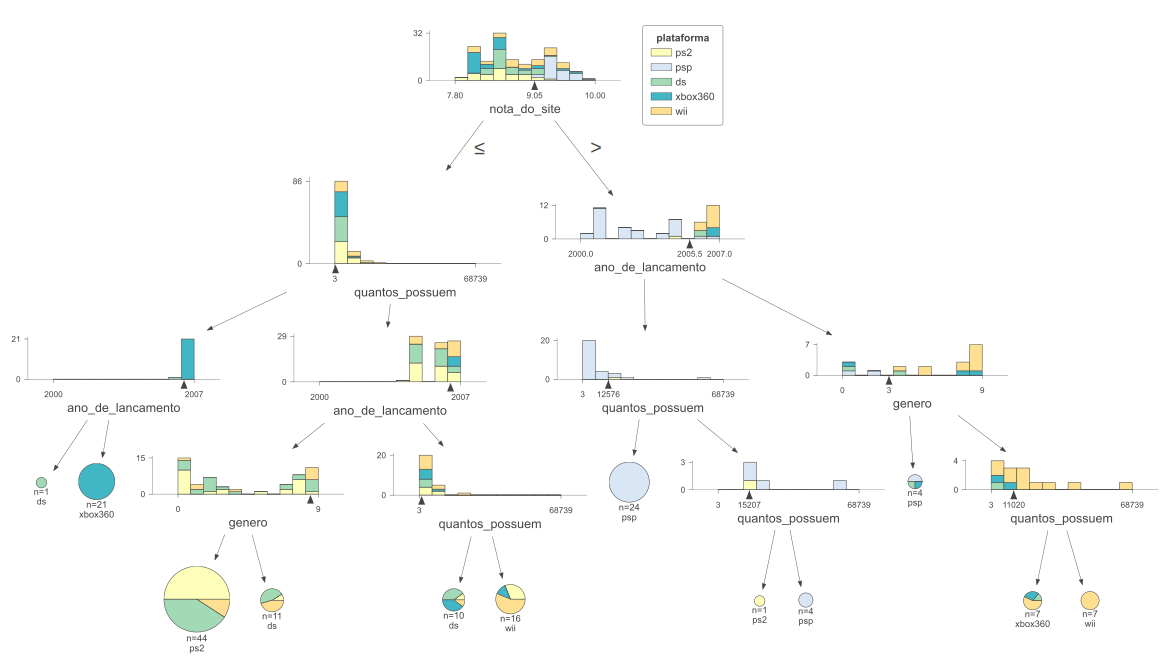

In [15]:
import dtreeviz

viz = dtreeviz.model(
    clf, 
    data,
    target,
    target_name='plataforma',
    feature_names=data.columns.to_list(), 
    class_names=['ps2','psp','ds','xbox360','wii']
)

# In a notebook, you can render inline without calling show()
viz.view(scale=1.4)

In [ ]:
# Uncomment to save with scale 1
vizRender = viz.view(scale=1.0)
vizRender.save("ign_games_decision_tree.svg")